In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
df = pd.read_csv("../DATA/processed/loan_feature_engineered.csv")

In [3]:
df.shape
df.head()

,loan_id,applicant_id,customer_name,gender,date_of_birth,age,marital_status,education,occupation,employment_type,employer_name,years_with_employer,annual_income,monthly_income,city,state,pincode,branch_id,branch_name,region,loan_product,loan_purpose,loan_amount,sanctioned_amount,disbursed_amount,interest_rate,tenure_months,emi_amount,processing_fee,credit_score,debt_to_income_ratio,existing_loans_count,existing_emi_obligations,collateral_type,collateral_value,co_applicant_flag,application_date,approval_date,disbursal_date,loan_status,default_flag,days_past_due,npa_flag,recovery_amount,loan_officer_id,loan_officer_name,payment_history_score,bounce_count,risk_category,customer_segment,is_fraud_suspected,kyc_verified,channel,age_group,income_category,credit_score_category,loan_amount_category,emi_to_income_ratio,loan_utilization,approval_percentage,high_risk_flag,loan_count_category
0,LN157322,AP257322,Sunil Mukherjee,Male,1998-10-02,28,Married,Post Graduate,Retail Business Owner,Business Owner,Self Employed,7.8,723600.0,43900.0,Gurugram,Haryana,140909,BR013,Gurugram City Branch,North,Personal Loan,Medical Emergency,552000.0,542000.0,539000.0,18.32,48,15923.0,6594.0,680.0,0.756,2,17250.0,NaN,0.0,Yes,2025-09-21,2025-09-27,2025-10-01,Default,1,228.0,Yes,95223.0,OFF0073,Vivaan Kulkarni,446.0,5,Low,Mass Market,No,Yes,Digital App,26-35,Medium,Good,Large,0.363,0.994,98.19,0,1-2
1,LN200595,AP300595,Dinesh Naidu,Male,2003-04-13,23,Married,Post Graduate,Trading Company Owner,Business Owner,Self Employed,10.1,685200.0,57100.0,Patna,Bihar,424815,BR014,Patna City Branch,East,Personal Loan,Travel,237000.0,235000.0,232000.0,17.00,51,6419.0,1947.0,697.0,0.151,1,2212.0,NaN,0.0,No,2023-01-26,2023-01-28,2023-01-30,Active,0,0.0,No,0.0,OFF0080,Aarav Patil,900.0,1,Low,Mass Market,No,Yes,Digital App,18-25,Medium,Good,Small,0.112,0.987,99.16,0,1-2
2,LN152399,AP252399,Karan Naidu,Male,1990-02-11,36,Divorced,Professional Degree,Manager,Salaried,Tata Motors,0.5,816000.0,68000.0,Chennai,Tamil Nadu,161492,BR019,Chennai City Branch,South,Gold Loan,Emergency Cash Need,912000.0,870000.0,853000.0,10.50,16,57364.0,16721.0,633.0,0.844,0,0.0,Gold Ornaments,0.0,No,2025-07-23,2025-08-01,2025-08-04,Active,0,0.0,No,0.0,OFF0112,Usha Sinha,836.0,1,Low,Mass Affluent,No,Yes,Branch Walk-in,36-45,High,Fair,Very Large,0.844,0.980,95.39,0,No Loan
3,LN192773,AP292773,Vihaan Rathore,Male,1979-11-04,47,Married,Professional Degree,Bank Employee,Salaried,Accenture,1.9,2404800.0,200400.0,Rohini,Delhi,351737,BR003,Rohini City Branch,North,Personal Loan,Education,1722000.0,1682000.0,1643000.0,17.01,50,46092.0,8461.0,465.0,0.297,1,13431.0,NaN,0.0,No,2025-05-07,2025-06-07,2025-07-09,Active,0,0.0,No,0.0,OFF0015,Aarav More,868.0,0,Low,Premium,No,Yes,Corporate Tie-up,46-55,Very High,Poor,Very Large,0.230,0.977,97.68,0,1-2
4,LN133442,AP233442,Komal Pillai,Female,1974-11-06,52,Married,Post Graduate,Freelancer,Self-Employed Business,Self Employed,3.0,633600.0,52800.0,Ludhiana,Punjab,267456,BR025,Ludhiana Main Branch,North,Personal Loan,Travel,562000.0,511000.0,509000.0,16.83,43,15844.0,6414.0,699.0,0.300,0,0.0,NaN,0.0,No,2025-09-14,2025-09-23,2025-09-26,Active,0,0.0,No,0.0,OFF0146,Sneha Bhatt,882.0,0,Low,Mass Market,No,Yes,Tele-calling,46-55,Medium,Good,Large,0.300,0.996,90.93,0,No Loan


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120720 entries, 0 to 120719
Data columns (total 62 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   loan_id                   120720 non-null  str    
 1   applicant_id              120720 non-null  str    
 2   customer_name             120720 non-null  str    
 3   gender                    120720 non-null  str    
 4   date_of_birth             120720 non-null  str    
 5   age                       120720 non-null  int64  
 6   marital_status            120720 non-null  str    
 7   education                 120720 non-null  str    
 8   occupation                120720 non-null  str    
 9   employment_type           120720 non-null  str    
 10  employer_name             120720 non-null  str    
 11  years_with_employer       120720 non-null  float64
 12  annual_income             120720 non-null  float64
 13  monthly_income            120720 non-null  float64
 14 

In [5]:
print(f"Total Loans : {df.shape[0]:,}")
print(f"Total Customers : {df['applicant_id'].nunique():,}")
print(f"Total Loan Amount : ₹{df['loan_amount'].sum():,.0f}")
print(f"Total Disbursed Amount : ₹{df['disbursed_amount'].sum():,.0f}")


Total Loans : 120,720
Total Customers : 120,000
Total Loan Amount : ₹73,416,032,795
Total Disbursed Amount : ₹67,577,245,000


In [6]:
#Loan Status Distribution
df["loan_status"].value_counts()
df["loan_status"].value_counts(normalize=True) * 100

loan_status
Active         69.801193
Closed         24.879887
Default         4.921306
Written-Off     0.397614
Name: proportion, dtype: float64

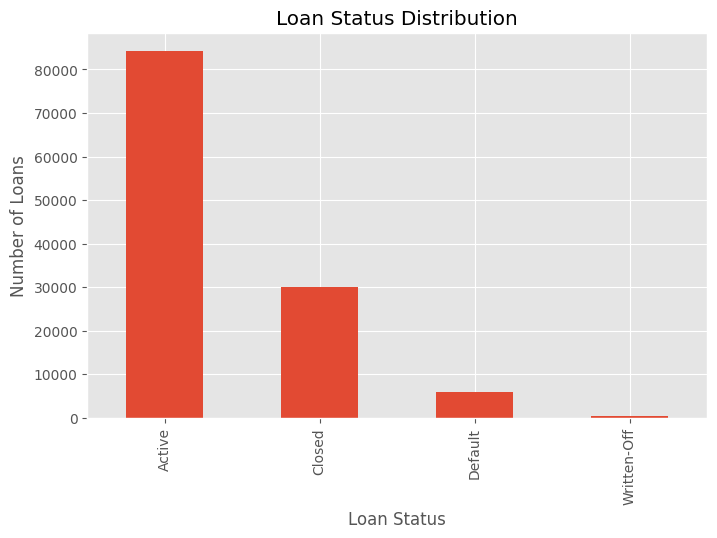

In [7]:
plt.figure(figsize=(8,5))

df["loan_status"].value_counts().plot(kind="bar")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")
plt.show()

In [8]:
default_rate = (
    df["default_flag"].mean() * 100
)

print(f"Default Rate : {default_rate:.2f}%")

Default Rate : 5.32%


In [9]:
df["credit_score"].mean()

np.float64(679.8342196819085)

In [10]:
df["emi_amount"].mean()

np.float64(23638.618149436712)

In [11]:
(
    df.groupby("state")["loan_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state
Karnataka        5.966461e+09
Punjab           5.925557e+09
West Bengal      5.920398e+09
Gujarat          5.899567e+09
Telangana        5.891275e+09
Delhi            5.878913e+09
Uttar Pradesh    5.848163e+09
Maharashtra      5.826072e+09
Tamil Nadu       5.807188e+09
Rajasthan        5.777919e+09
Name: loan_amount, dtype: float64

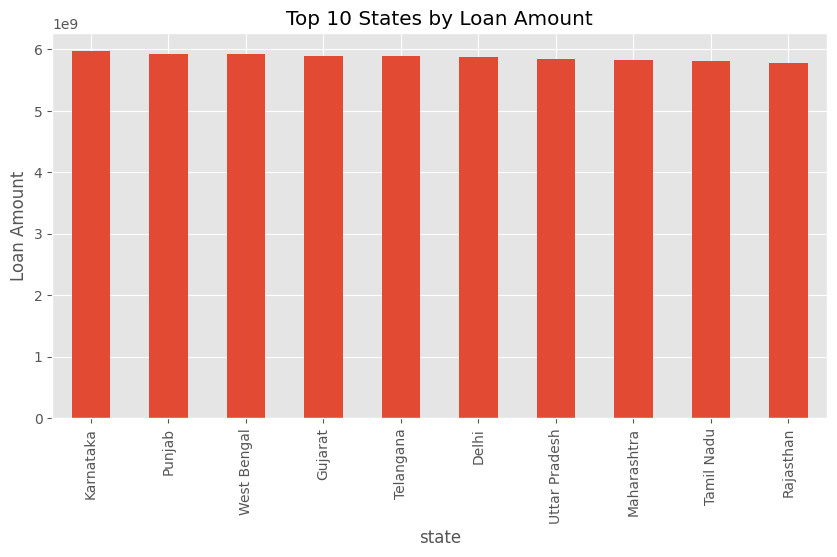

In [12]:
(
    df.groupby("state")["loan_amount"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .plot(kind="bar", figsize=(10,5))
)

plt.title("Top 10 States by Loan Amount")
plt.ylabel("Loan Amount")
plt.show()